In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Configuramos el estilo de las gráficas para que se vean más profesionales
sns.set_theme(style="whitegrid")

# Fijamos una semilla para que el azar sea siempre el mismo 
torch.manual_seed(42)
np.random.seed(42)
df = pd.read_csv('insurance.csv')


# Exploratory Data Analysis (EDA):

In [11]:
print("--- PRIMERAS FILAS DEL DATASET ---")
display(df.head())

print("\n--- INFORMACIÓN GENERAL Y VALORES NULOS ---")
display(df.info())
print("Valores nulos por columna:\n", df.isnull().sum())

print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

--- PRIMERAS FILAS DEL DATASET ---


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- INFORMACIÓN GENERAL Y VALORES NULOS ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None

Valores nulos por columna:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- ESTADÍSTICAS DESCRIPTIVAS ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


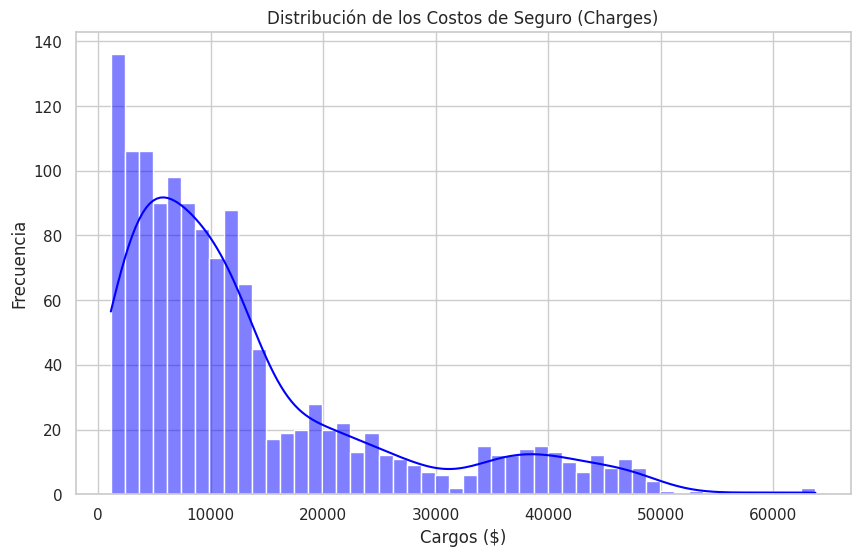

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], kde=True, color='blue', bins=50)
plt.title('Distribución de los Costos de Seguro (Charges)')
plt.xlabel('Cargos ($)')
plt.ylabel('Frecuencia')
plt.show()

In [14]:

# Transformamos categorías en columnas de 0 y 1 ya que nuestro modelo no puede trabajar con texto porque las redes neuronales trabajan con números, no con texto.
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)   #el drop_first=True es para evitar redundacia, es decir que si no es hombre, entonces es mujer, si no es fumador, entonces es no fumador, etc.

# Separamos las características (X) de la variable objetivo (y) que es 'charges'. 
X = df.drop('charges', axis=1).values
y = df['charges'].values.reshape(-1, 1)



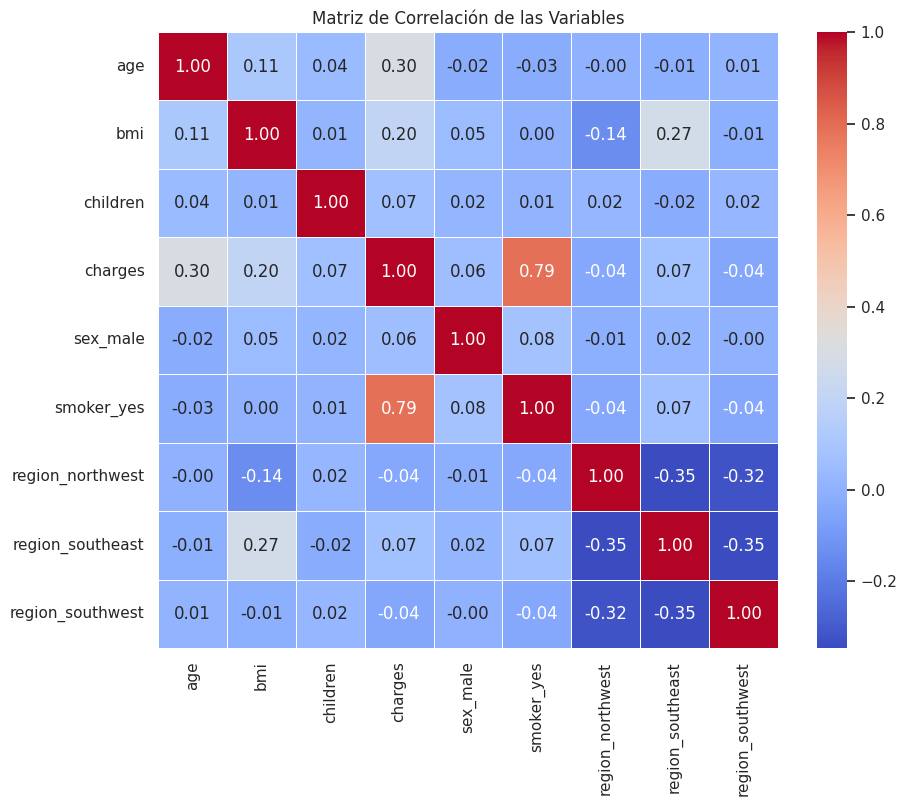

In [15]:
plt.figure(figsize=(10, 8))
# Calculamos la correlación
correlacion = df.corr()
# Dibujamos un mapa de calor (heatmap)
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de las Variables')
plt.show()

/tmp/ipykernel_97286/790347924.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='smoker_yes', y='charges', data=df, palette='Set2')


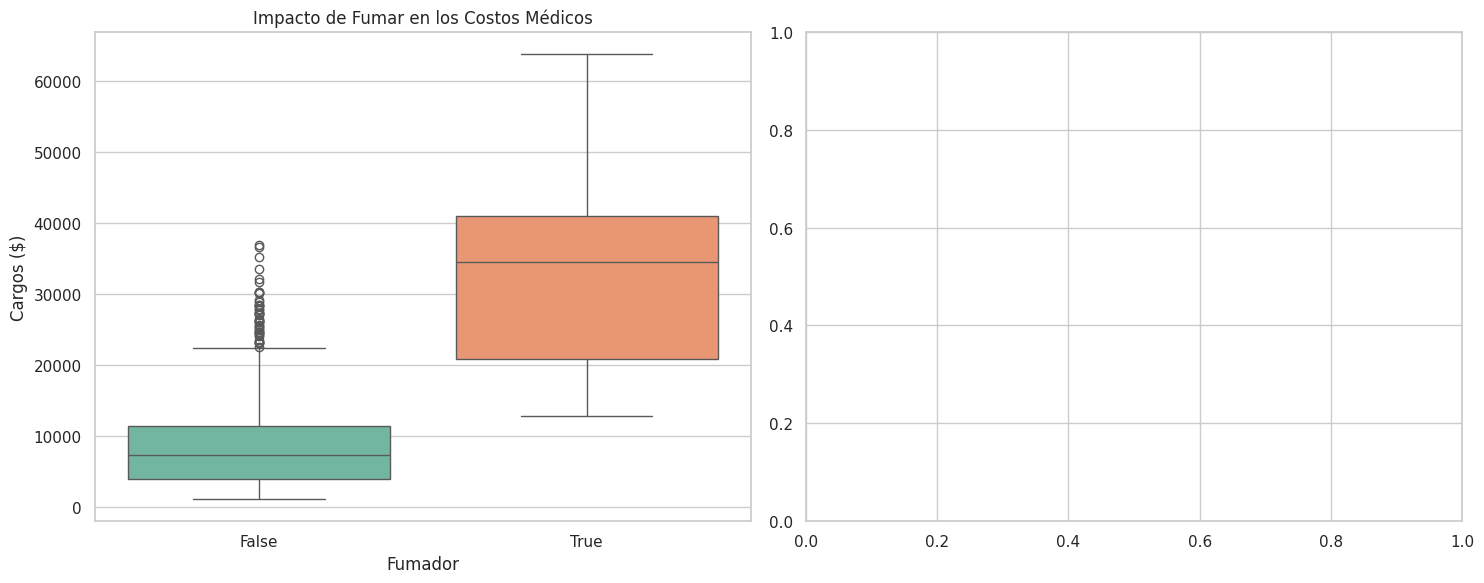

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: Fumador vs Cargos
sns.boxplot(ax=axes[0], x='smoker_yes', y='charges', data=df, palette='Set2')
axes[0].set_title('Impacto de Fumar en los Costos Médicos')
axes[0].set_xlabel('Fumador')
axes[0].set_ylabel('Cargos ($)')



plt.tight_layout()
plt.show()

In [3]:
# Separamos 80% para entrenar y 20% para el resto
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Ese 20% lo dividimos en dos: 10% para Validar y 10% para el Test final
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [4]:


#Estandarizamos los datos porque las redes neuronales funcionan mejor con datos centrados y escalados
#Si no lo hacemos, algunas características podrían dominar a otras debido a sus diferentes escalas, lo que podría dificultar el aprendizaje del modelo.
scaler = StandardScaler()

# Ajustamos el scaler solo con los datos de entrenamiento para evitar "fugas de información" 
X_train = scaler.fit_transform(X_train)

# Luego transformamos los datos de validación y test usando el mismo scaler para mantener la consistencia
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



# La red neuronal no entiende tablas de Excel o listas normales, solo entiende "Tensores".
# Convertimos los números a Floats (decimales) para que el motor de PyTorch pueda hacer cálculos rápidos.
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)

X_test, y_test = torch.FloatTensor(X_test), torch.FloatTensor(y_test)

In [5]:
import torch.nn as nn
import torch.nn.init as init

# Definimos la estructura de nuestra red neuronal. 
class RedSeguros(nn.Module):
    def __init__(self, input_dim):
        super(RedSeguros, self).__init__()
        
        # CAPA 1: Recibe los datos y los pasa a 64 neuronas
        self.capa1 = nn.Linear(input_dim, 64)
        
        # CAPA 2: Pasa de 64 neuronas a 32 neuronal ya que hacer redes profundas ("Deep") es más eficiente que redes anchas.
        self.capa2 = nn.Linear(64, 32)
        
        # CAPA DE SALIDA: De 32 neuronas a 1 sola que es el valor que queremos predecir (el costo del seguro).
        self.salida = nn.Linear(32, 1)
        
        # FUNCIÓN DE ACTIVACIÓN: Sirve para que la red aprenda relaciones complejas, no solo líneas rectas.
        self.relu = nn.ReLU()
        
        # INICIALIZACIÓN DE HE/KAIMING NORMAL: Esto ayuda a que la red aprenda mejor al empezar con pesos adecuados.
        init.kaiming_normal_(self.capa1.weight)
        init.kaiming_normal_(self.capa2.weight)
        init.kaiming_normal_(self.salida.weight)

    def forward(self, x):
        # Aquí definimos el camino que siguen los datos
        x = self.relu(self.capa1(x)) # Pasa por capa 1 y aplica ReLU
        x = self.relu(self.capa2(x)) # Pasa por capa 2 y aplica ReLU
        x = self.salida(x)           # Pasa por la salida (aquí no hay ReLU porque es regresión)
        return x

# Creamos el modelo usando el número de columnas que tiene X_train
modelo = RedSeguros(X_train.shape[1])





In [6]:
#necesitamos ahora ver cuanto se equivoca la red y como mejorarlo

# La función de pérdida (loss function) mide cuánto se equivoca el modelo. 
# Para problemas de regresión como este, es común usar el MSE que penaliza más los errores grandes.
criterion = nn.MSELoss()

# El optimizer va a ser  el algoritmo que ajusta los pesos de la red para minimizar la pérdida.
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.001)   ## Usamos Adam porque es más rápido que el Gradient Descent normal y se adapta solo.

In [7]:
#Este es el bucle de entrenamiento 

# Decidimos cuántas veces va a estudiar el dataset completo
epochs = 300 
historial_error = []

for epoch in range(epochs):
    # Ponemos el modelo en modo entrenamiento
    modelo.train()
    
    # Reseteamos los gradientes antes de cada paso para que no se acumulen
    optimizer.zero_grad()
    
    # La red hace su predicción con los datos de entrenamiento
    predicciones = modelo(X_train)
    
    # Comparamos la predicción con el precio real
    loss = criterion(predicciones, y_train)
    
    #  La red va hacia atrás para ver quién tuvo la culpa del error
    loss.backward()
    
    # El optimizador ajusta los pesos basándose en el error
    optimizer.step()
    
    # Guardamos el error para ver luego si ha bajado
    historial_error.append(loss.item())
    
    # Imprimimos el progreso cada 50 pasos
    if (epoch + 1) % 50 == 0:
        print(f'Época {epoch+1}/{epochs} - Error actual: {loss.item():.4f}')

Época 50/300 - Error actual: 321972384.0000
Época 100/300 - Error actual: 320980000.0000
Época 150/300 - Error actual: 319022720.0000
Época 200/300 - Error actual: 315575392.0000
Época 250/300 - Error actual: 310110912.0000
Época 300/300 - Error actual: 302161024.0000


In [8]:
#convertir el TEST a tensores 
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

#creamos una lista para guardar el error de validación
historial_v_error = []